# AAV2 -- vue d'ensemble du dataset brut

Notebook de reference rapide sur `AAV2_organoides.csv` -- pas de filtre, pas de regression,
juste les chiffres de base pour s'orienter :

1. `pandas.describe()` sur toutes les colonnes numeriques.
2. Nombre de reads a chaque etape (checkpoint) -- total, reads/variant (moyenne+mediane, sur
   l'ensemble ET parmi les variants detectes), fraction de variants detectes, table de comptage
   par seuil (`analysisV1.number_of_seq_threshold`).
3. Top 100 sequences par colonne (comptages ET log2 enrichissements).

**Notebook prepare mais jamais execute par Claude** (`feedback_user_runs_notebooks`).

### 0. Setup

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
from analysisV1 import number_of_seq_threshold

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

CSV = Path("AAV2_organoides.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/AAVs dataset/AAV2/AAV2_organoides.csv"
assert CSV.exists(), CSV

df = pd.read_csv(CSV)
print(f"{CSV.name} : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.dtypes

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AAV2_organoides.csv : 4,273,463 lignes x 34 colonnes


sequence                                                str
compte_plasmide                                       int64
compte_virus                                          int64
log2_enrichissement_virus_sur_plasmide              float64
compte_organoide_1_adn                              float64
compte_organoide_1_arn                              float64
log2_enrichissement_organoide_1_adn_sur_virus       float64
log2_enrichissement_organoide_1_arn_sur_virus       float64
log2_enrichissement_organoide_1_arn_sur_adn         float64
compte_organoide_2_adn                              float64
compte_organoide_2_arn                              float64
log2_enrichissement_organoide_2_adn_sur_virus       float64
log2_enrichissement_organoide_2_arn_sur_virus       float64
log2_enrichissement_organoide_2_arn_sur_adn         float64
compte_organoide_3_adn                              float64
compte_organoide_3_arn                              float64
log2_enrichissement_organoide_3_adn_sur_

### 1. `pandas.describe()` -- toutes les colonnes numeriques

Percentiles etendus (`.01`/`.05`/`.95`/`.99` en plus des quartiles par defaut) -- les colonnes de
comptage sont a queue tres lourde, les quartiles seuls masquent la queue.

In [2]:
numeric_cols = df.columns.drop("sequence")
stats = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
stats

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
compte_plasmide,4273463.0,2.304338,3.011641,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,8.000000,14.000000,6.100000e+01
compte_virus,4273463.0,58.058740,1727.625456,1.000000,1.000000,1.000000,1.000000,3.000000,8.000000,62.000000,645.000000,1.081060e+06
log2_enrichissement_virus_sur_plasmide,2810598.0,0.668652,2.377089,-5.826091,-3.366659,-2.629693,-1.044731,0.177662,1.955269,4.999663,8.303112,1.924462e+01
compte_organoide_1_adn,4273463.0,9.566763,434.530683,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,126.500000,4.124660e+05
compte_organoide_1_arn,4273463.0,7.813084,573.398609,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.474385e+05
log2_enrichissement_organoide_1_adn_sur_virus,215466.0,1.686589,3.110119,-12.080079,-6.299858,-3.506517,-0.309216,1.634522,3.706306,6.941083,8.395717,1.348908e+01
log2_enrichissement_organoide_1_arn_sur_virus,64530.0,-1.355509,4.542325,-14.833449,-10.091682,-8.441245,-5.161577,-1.108461,2.134881,5.351430,9.337823,1.629641e+01
log2_enrichissement_organoide_1_arn_sur_adn,49012.0,-2.830503,4.495408,-11.757070,-9.459296,-8.451706,-6.638851,-4.246775,0.487179,4.506567,9.568634,1.197054e+01
compte_organoide_2_adn,4273463.0,8.432203,341.728547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.500000,2.255370e+05
compte_organoide_2_arn,4273463.0,9.180453,566.812569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.197635e+05


### 2. Reads a chaque etape (checkpoint)

Une ligne par colonne `compte_*` (chaque colonne = un checkpoint : plasmide = librairie
initiale, virus = post-viabilite, organoide/noyaux = post-selectivite par replicat/compartiment).
`reads/variant` a deux variantes : sur TOUT le dataset (total_reads / n_lignes -- inclut les
variants a 0) et parmi les variants REELEMENT detectes (`count>0`) -- l'ecart entre les deux
mesure directement la severite de l'attrition a ce checkpoint.

In [3]:
count_cols = [c for c in df.columns if c.startswith("compte_")]
n_total = len(df)

reads_summary = pd.DataFrame({
    c: {
        "total_reads": int(df[c].sum()),
        "reads/variant (tout le dataset)": df[c].sum() / n_total,
        "n_variants>0": int((df[c] > 0).sum()),
        "fraction>0": (df[c] > 0).mean(),
        "reads/variant (parmi >0), moyenne": df.loc[df[c] > 0, c].mean(),
        "reads/variant (parmi >0), mediane": df.loc[df[c] > 0, c].median(),
    }
    for c in count_cols
}).T
reads_summary

,total_reads,reads/variant (tout le dataset),n_variants>0,fraction>0,"reads/variant (parmi >0), moyenne","reads/variant (parmi >0), mediane"
compte_plasmide,9847502.0,2.304338,2810598.0,0.657686,3.503703,3.0
compte_virus,248111879.0,58.058740,4273463.0,1.000000,58.058740,3.0
compte_organoide_1_adn,40883207.0,9.566763,215466.0,0.050420,189.743194,48.0
compte_organoide_1_arn,33388925.0,7.813084,64530.0,0.015100,517.417093,1.5
compte_organoide_2_adn,36034706.0,8.432203,131845.0,0.030852,273.311134,84.0
compte_organoide_2_arn,39232324.0,9.180453,65303.0,0.015281,600.773693,1.5
compte_organoide_3_adn,46127817.0,10.794014,183342.0,0.042902,251.594384,77.5
compte_organoide_3_arn,41792134.0,9.779454,63850.0,0.014941,654.536171,2.0
compte_noyaux_1_adn,37929389.0,8.875563,75240.0,0.017606,504.112028,4.0
compte_noyaux_1_arn,43826321.0,10.255458,60142.0,0.014073,728.714068,1.5


In [4]:
thresholds_table = number_of_seq_threshold(
    lambdas={c: df[c].to_numpy() for c in count_cols},
    thresholds=[1, 10, 100, 1000],
)
thresholds_table

,1.0,10.0,100.0,1000.0
lambda,,,,
compte_plasmide,2810598,138737,0,0
compte_virus,4273463,919408,152474,30355
compte_organoide_1_adn,208684,158907,55066,5051
compte_organoide_1_arn,58710,12142,9950,6954
compte_organoide_2_adn,125936,76726,63163,5210
compte_organoide_2_arn,58994,10812,7793,7307
compte_organoide_3_adn,176623,133989,66064,6079
compte_organoide_3_arn,57839,17722,16169,7155
compte_noyaux_1_adn,69423,34802,32781,6941


### 3. Top 100 sequences par colonne

Un `nlargest(100, colonne)` pour chaque colonne numerique (comptages ET log2 enrichissements) --
stocke integralement dans `top100[colonne]` (100 lignes chacun), seul le top 10 est affiche ici
pour rester lisible.

In [5]:
value_cols = [c for c in df.columns if c != "sequence"]
top100 = {c: df.nlargest(100, c)[["sequence", c]].reset_index(drop=True) for c in value_cols}
print(f"top100 calcule pour {len(top100)} colonnes -- top100['<colonne>'] pour les 100 lignes completes")

top100 calcule pour 33 colonnes -- top100['<colonne>'] pour les 100 lignes completes


In [6]:
for c in value_cols:
    print(f"--- top 10 (sur 100 calcules) : {c} ---")
    display(top100[c].head(10))

--- top 10 (sur 100 calcules) : compte_plasmide ---


,sequence,compte_plasmide
0,AGASERP,61
1,IRRDLCA,61
2,SAMSRAP,61
3,TMAIEAA,56
4,VKWCFSM,56
5,FDRDLCA,55
6,NLMSRAP,55
7,TPAWSCN,54
8,AARAMEQ,51
9,ATEWPKP,51


--- top 10 (sur 100 calcules) : compte_virus ---


,sequence,compte_virus
0,EGNPNRF,1081060
1,PDRAMGH,877578
2,DPYDKRQ,640727
3,EPTNNKG,551410
4,IPGDRHL,541575
5,GAHDRMT,518344
6,DQQPQKI,471799
7,GAKPEGH,445759
8,GTGAGHM,444763
9,GERVGRE,429528


--- top 10 (sur 100 calcules) : log2_enrichissement_virus_sur_plasmide ---


...

,sequence,log2_enrichissement_noyaux_moyenne_adn_sur_virus
0,MQRDLFA,13.592765
1,GTSNVHM,13.270970
2,EGELLNY,13.213844
3,VDELYDA,13.123676
4,SIAHQMI,12.943809
5,KEAGMGH,12.641200
6,KPQGVNH,12.579007
7,ENWVLEI,12.552189
8,TDVGNQY,12.498529
9,VMNQQKM,12.469576


--- top 10 (sur 100 calcules) : log2_enrichissement_noyaux_moyenne_arn_sur_virus ---


,sequence,log2_enrichissement_noyaux_moyenne_arn_sur_virus
0,DPQLGYT,15.947776
1,HQPSNQF,15.475787
2,RKDWDSL,15.309531
3,DTKWVNW,15.255480
4,LGANTNY,15.033599
5,TYAAERP,14.741761
6,NISVKQT,14.699407
7,SPNYKVD,14.609176
8,MCMKAVD,14.604280
9,GTDQFAF,14.568584


--- top 10 (sur 100 calcules) : log2_enrichissement_noyaux_moyenne_arn_sur_adn ---


,sequence,log2_enrichissement_noyaux_moyenne_arn_sur_adn
0,MPDHGFP,13.747413
1,DMPTQQD,13.646958
2,SANTIGH,13.459325
3,AMSKVTS,13.267486
4,QMIIHNN,13.250274
5,QTAELAA,13.205811
6,SKPQIDN,13.193537
7,LDEFGHK,13.185841
8,TGMHYKE,13.139084
9,TYAAERP,13.135016


### 4. Org1 vs org2 vs org3 -- accord entre replicats (log2 enrichissement organoide ADN/virus)

Scatter pairwise (hexbin + diagonale y=x + Pearson r) sur les 3 colonnes
`log2_enrichissement_organoide_{1,2,3}_adn_sur_virus` -- tout le dataset, seule contrainte : les
deux valeurs finies pour la paire consideree (pas de filtre supplementaire).

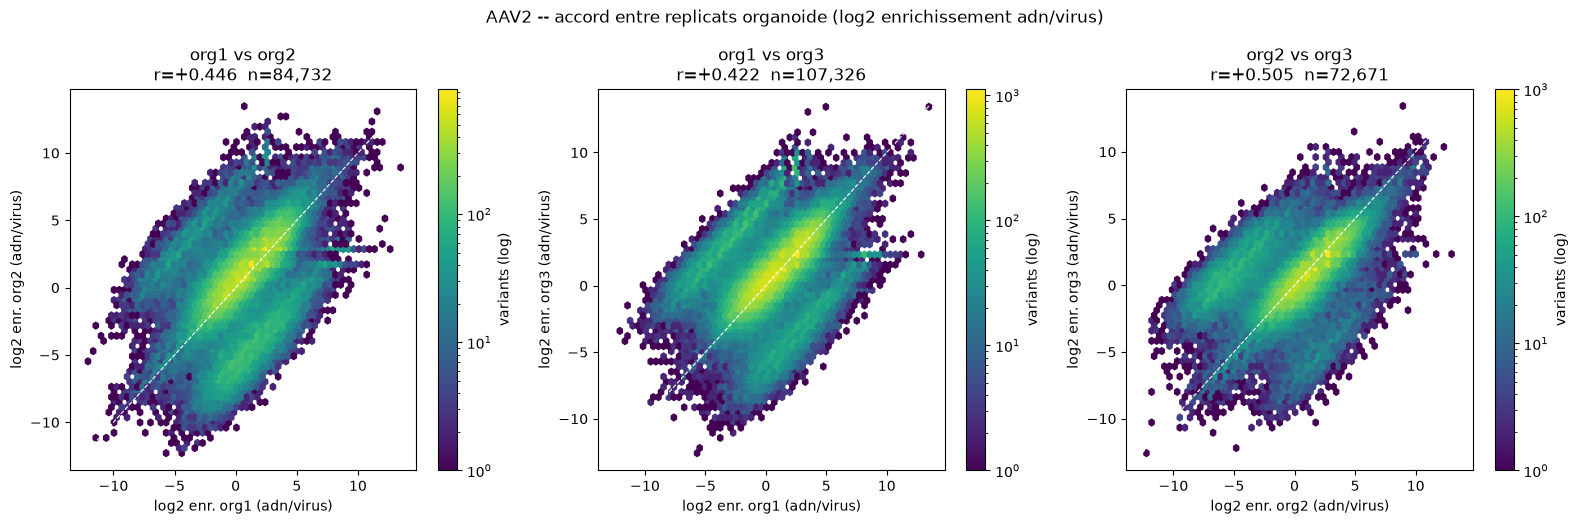

In [7]:
import matplotlib.pyplot as plt
from itertools import combinations
from analysisV1 import pearson

org_cols = {i: f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, (i, j) in zip(axes, combinations(org_cols, 2)):
    xi = df[org_cols[i]].to_numpy(np.float64)
    yj = df[org_cols[j]].to_numpy(np.float64)
    m = np.isfinite(xi) & np.isfinite(yj)
    r = pearson(xi[m], yj[m])
    hb = ax.hexbin(xi[m], yj[m], gridsize=60, bins="log", cmap="viridis", mincnt=1)
    lo, hi = min(xi[m].min(), yj[m].min()), max(xi[m].max(), yj[m].max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"org{i} vs org{j}\nr={r:+.3f}  n={int(m.sum()):,}",
           xlabel=f"log2 enr. org{i} (adn/virus)", ylabel=f"log2 enr. org{j} (adn/virus)")
    fig.colorbar(hb, ax=ax, label="variants (log)")
fig.suptitle("AAV2 -- accord entre replicats organoide (log2 enrichissement adn/virus)")
plt.tight_layout(); plt.show()